# Práctica: OpenCV en Python (detección de rostros y color)

**Materia:** Recuperación de la Información

Esta práctica complementa la de `cv2` con dos casos de uso distintos: **detección de rostros** con clasificadores en cascada y **segmentación por color** en el espacio HSV.

## ¿Para qué sirve?

OpenCV permite ir más allá del procesamiento básico de píxeles: incluye modelos y algoritmos preentrenados (como los clasificadores Haar) para **detectar objetos específicos** (rostros, ojos, cuerpos), y herramientas para **segmentar imágenes por color**, lo cual es la base de tareas como seguimiento de objetos, control por gestos, o extracción de regiones de interés en una imagen.

## ¿Cómo funciona?

- **Detección de rostros (Haar Cascades):** un clasificador en cascada es un modelo entrenado con miles de imágenes positivas (rostros) y negativas (no rostros) que aprende patrones de contraste típicos de un rostro (ojos más oscuros que las mejillas, la nariz más clara, etc.). OpenCV lo aplica en ventanas deslizantes sobre la imagen a distintas escalas hasta encontrar coincidencias.
- **Segmentación por color (HSV):** en vez de trabajar en RGB/BGR (donde el color y el brillo están mezclados), se convierte la imagen al espacio **HSV** (matiz, saturación, valor), donde el matiz (Hue) representa el color puro. Definiendo un rango de matiz se puede crear una máscara binaria que aísla únicamente los píxeles de ese color.

## ¿Qué tipo de operaciones se pueden realizar?

- Cargar un **clasificador en cascada** preentrenado (`cv2.CascadeClassifier`).
- **Detectar rostros/objetos** con `detectMultiScale`.
- Convertir a **espacio de color HSV** (`cv2.cvtColor(..., cv2.COLOR_BGR2HSV)`).
- Crear una **máscara** por rango de color (`cv2.inRange`).
- Aplicar la máscara con `cv2.bitwise_and` para aislar una región.
- **Operaciones morfológicas** (erosión/dilatación) para limpiar ruido en la máscara.
- Calcular el **centroide** de una región detectada (útil para seguimiento de objetos).

## Antes de empezar: si `import cv2` se queda "trabado" (celda en `[*]` para siempre)

Este es un problema **muy conocido de `opencv-python` en Windows**, no un error de este notebook: el paquete `opencv-python` completo incluye backends de video/GUI (Media Foundation, DirectShow, ventanas nativas) que en algunas laptops (sobre todo con software de cámara del fabricante, o Snap Camera/OBS instalados) se quedan colgados intentando enumerar dispositivos de video **desde el simple `import cv2`**, aunque el notebook nunca use una cámara.

**Solución recomendada (2 pasos):**

1. Desinstala `opencv-python` e instala la versión **headless** (misma librería `cv2`, sin los backends de GUI/cámara que causan el congelamiento — es justo la versión pensada para notebooks/servidores):
   ```
   pip uninstall opencv-python -y
   pip install opencv-python-headless
   ```
2. Como respaldo adicional, este notebook desactiva esos backends problemáticos **antes** de importar `cv2` (ver la primera celda de código). Si aun así se queda trabado, reinicia el kernel después de instalar `opencv-python-headless`.

In [1]:
# Desactivar backends de video/hardware que pueden colgar el import de cv2 en Windows
import os
os.environ.setdefault('OPENCV_VIDEOIO_PRIORITY_MSMF', '0')
os.environ.setdefault('OPENCV_VIDEOIO_PRIORITY_DSHOW', '0')
os.environ.setdefault('OPENCV_VIDEOIO_PRIORITY_INTEL_MFX', '0')

import cv2
import numpy as np
import matplotlib.pyplot as plt

cv2.ocl.setUseOpenCL(False)
print('cv2 importado correctamente, version:', cv2.__version__)

cv2 importado correctamente, version: 4.11.0


## Ejemplo 1: detección de rostros con Haar Cascade

Usamos una **fotografía real** (la imagen de muestra `astronaut` incluida en `scikit-image`, un retrato real de una persona) en vez de una figura sintética, porque los clasificadores Haar están entrenados con fotos reales y casi nunca detectan nada en formas dibujadas a mano (círculos y óvalos).

In [2]:
print('Clasificadores disponibles en cv2.data.haarcascades, por ejemplo:')
print(' -', cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print('¿Clasificador cargado correctamente?', not face_cascade.empty())

Clasificadores disponibles en cv2.data.haarcascades, por ejemplo:
 - /sessions/intelligent-practical-bell/.local/lib/python3.10/site-packages/cv2/data/haarcascade_frontalface_default.xml
¿Clasificador cargado correctamente? True


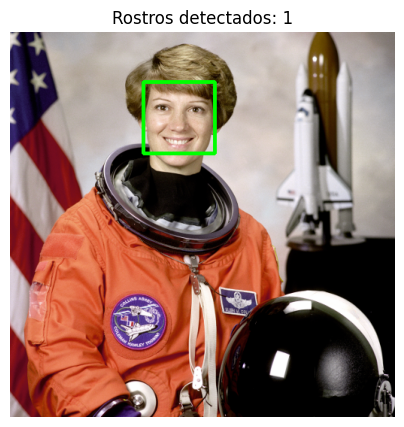

Coordenadas de rostro(s) detectado(s) (x, y, ancho, alto): [[177  66  95  95]]


In [3]:
from skimage import data

# Fotografia real (incluida localmente en scikit-image, no requiere internet)
img_rgb = data.astronaut()
img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

img_out = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_out, (x, y), (x+w, y+h), (0, 255, 0), 3)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
plt.title(f'Rostros detectados: {len(faces)}')
plt.axis('off')
plt.show()

print('Coordenadas de rostro(s) detectado(s) (x, y, ancho, alto):', faces)

## Ejemplo 2: segmentación por color en HSV

Creamos una imagen con tres círculos de colores distintos y aislamos únicamente el color rojo.

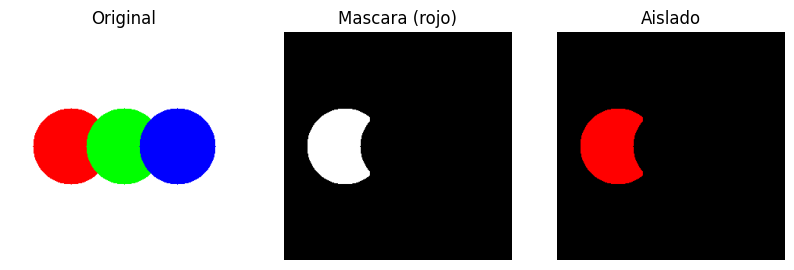

Centroide del objeto rojo: (71, 150)


In [4]:
img2 = np.full((300, 300, 3), 255, dtype=np.uint8)
cv2.circle(img2, (80, 150), 50, (0, 0, 255), -1)    # rojo (BGR)
cv2.circle(img2, (150, 150), 50, (0, 255, 0), -1)   # verde
cv2.circle(img2, (220, 150), 50, (255, 0, 0), -1)   # azul

hsv = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

# Rango de rojo en HSV (el rojo esta cerca de 0 y de 180 en el circulo de matiz)
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(hsv, lower_red, upper_red)

# Limpiar la mascara con morfologia
kernel = np.ones((5,5), np.uint8)
mask_limpia = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

resultado = cv2.bitwise_and(img2, img2, mask=mask_limpia)

fig, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(mask_limpia, cmap='gray'); axs[1].set_title('Mascara (rojo)')
axs[1].axis('off')
axs[2].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)); axs[2].set_title('Aislado')
axs[2].axis('off')
plt.show()

ys, xs = np.where(mask_limpia > 0)
if len(xs) > 0:
    print('Centroide del objeto rojo:', (int(xs.mean()), int(ys.mean())))

## Conclusión

Estos dos ejemplos muestran dos formas complementarias de "buscar" contenido dentro de una imagen: por **patrones aprendidos** (clasificadores en cascada, aquí probados sobre una fotografía real) y por **propiedades de color** (segmentación HSV). Ambas técnicas son la base de aplicaciones como seguimiento de objetos, control por gestos o sistemas de vigilancia.